In [1]:
import pandas as pd
import tqdm as tqdm
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import numpy as np
from scipy import stats

In [2]:
large_v3_path = "./transcribed_refined.csv"
monsoon_path = "./transcribed_monsoon_refined.csv"

header = ['filename', 'txt', 'model_transcript', 'cer']
df_large = pd.read_csv(large_v3_path, header=None, names=header, delimiter='|')
df_monsoon = pd.read_csv(monsoon_path, header=None, names=header, delimiter='|')

In [3]:
# Identify files where CER is <= 0.1 in each model
large_good_files = set(df_large[df_large['cer'] <= 0.1]['filename'])
monsoon_good_files = set(df_monsoon[df_monsoon['cer'] <= 0.1]['filename'])

# Get all unique filenames
all_files = set(df_large['filename']).union(set(df_monsoon['filename']))

# Calculate various sets
both_good = large_good_files.intersection(monsoon_good_files)
only_large_good = large_good_files - monsoon_good_files
only_monsoon_good = monsoon_good_files - large_good_files
both_bad = all_files - large_good_files - monsoon_good_files

print(f"Total files analyzed: {len(all_files)}")
print(f"Files where both versions align well (CER ≤ 0.1): {len(both_good)} ({len(both_good)/len(all_files):.2%})")
print(f"Files where only large_v3 aligns well: {len(only_large_good)} ({len(only_large_good)/len(all_files):.2%})")
print(f"Files where only monsoon aligns well: {len(only_monsoon_good)} ({len(only_monsoon_good)/len(all_files):.2%})")
print(f"Files where neither version aligns well: {len(both_bad)} ({len(both_bad)/len(all_files):.2%})")

Total files analyzed: 225028
Files where both versions align well (CER ≤ 0.1): 72831 (32.37%)
Files where only large_v3 aligns well: 26494 (11.77%)
Files where only monsoon aligns well: 22124 (9.83%)
Files where neither version aligns well: 103579 (46.03%)


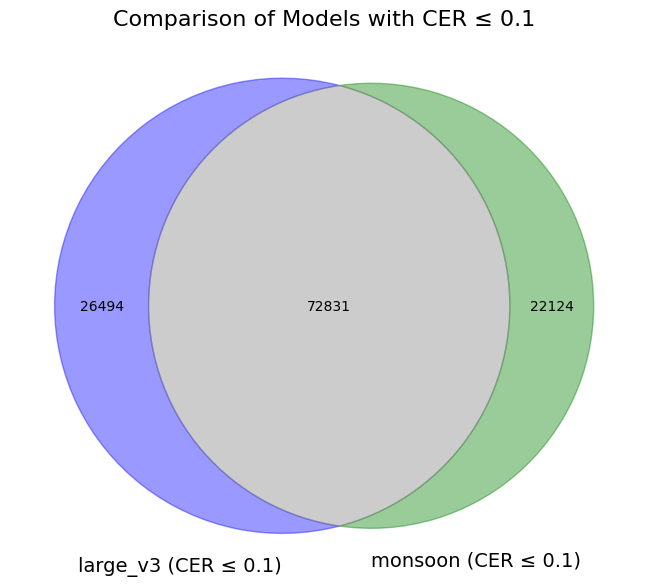


Average CER for large_v3: 0.2076
Average CER for monsoon: 0.1660


In [4]:
# Create Venn diagram
plt.figure(figsize=(10, 6))
v = venn2([large_good_files, monsoon_good_files], 
          set_labels=('large_v3 (CER ≤ 0.1)', 'monsoon (CER ≤ 0.1)'))

# Add count labels
for idx, text in enumerate(v.set_labels):
    text.set_fontsize(14)

# Customize colors
v.get_patch_by_id('10').set_color('blue')
v.get_patch_by_id('01').set_color('green')
v.get_patch_by_id('11').set_color('gray')

# Add a title
plt.title('Comparison of Models with CER ≤ 0.1', fontsize=16)
plt.tight_layout()
plt.show()

# Additional analysis: Compare average CER for each model
avg_cer_large = df_large['cer'].mean()
avg_cer_monsoon = df_monsoon['cer'].mean()

print(f"\nAverage CER for large_v3: {avg_cer_large:.4f}")
print(f"Average CER for monsoon: {avg_cer_monsoon:.4f}")

In [5]:
n_samples = 10

# Function to print samples with CER from both models
def print_samples(category_name, file_set):
    print(f"\n{category_name} (sample of {min(3, len(file_set))} rows):")
    if len(file_set) == 0:
        print("No samples in this category.")
        return
        
    sample_files = list(file_set)[:n_samples] if len(file_set) <= n_samples else random.sample(list(file_set), n_samples)
    
    for i, filename in enumerate(sample_files, 1):
        large_row = df_large[df_large['filename'] == filename].iloc[0]
        monsoon_row = df_monsoon[df_monsoon['filename'] == filename].iloc[0]
        
        print(f"{i}. Filename: {filename}")
        print(f"   Original: {large_row.txt[:50]}..." if len(large_row.txt) > 50 else f"   Original: {large_row.txt}")
        print(f"   Large_v3 (CER: {large_row.cer:.4f}): {large_row.model_transcript}")
        print(f"   Monsoon (CER: {monsoon_row.cer:.4f}): {monsoon_row.model_transcript}")
        print("-" * 80)

# Import random for sampling
import random

# Print samples from each category
print_samples("Both models good (CER ≤ 0.1)", both_good)
print_samples("Only large_v3 good", only_large_good)
print_samples("Only monsoon good", only_monsoon_good)
print_samples("Both models bad (CER > 0.1)", both_bad)


Both models good (CER ≤ 0.1) (sample of 3 rows):
1. Filename: ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0779/thai-central_352315_mic1.flac
   Original: แต่ใครจะรู้ว่านางจะล้มเหลวที่จะทำตามความคาดหวังและ...
   Large_v3 (CER: 0.0000): แต่ใครจะรู้ว่านางจะล้มเหลวที่จะทำตามความคาดหวังและทำสิ่งนั้นได้
   Monsoon (CER: 0.0635): แต่ใครจะรู้ว่านางจะล้มเหลวที่จะทําตามความคาดหวังและทําสิ่งนั้นได้
--------------------------------------------------------------------------------
2. Filename: ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0940/thai-central_303328_mic1.flac
   Original: อ่านแล้วอึ้งค่ะคงต้องขอเงินคืนอย่างเดียว
   Large_v3 (CER: 0.0500): อ่ะแล้วอึ้งค่ะคงต้องขอเงินคืนอย่างเดียว
   Monsoon (CER: 0.1000): แล้วอึ้งค่ะคงต้องขอเงินคืนอย่างเดียว
--------------------------------------------------------------------------------
3. Filename: ../data/converted/thai-central-to-vctk/wav16_silence_trimmed/tc0294/thai-central_433355_mic1.flac
   Original: พ่อทนเห็

Original data points: 225028
After removing outliers: 221027
Removed 4001 outliers


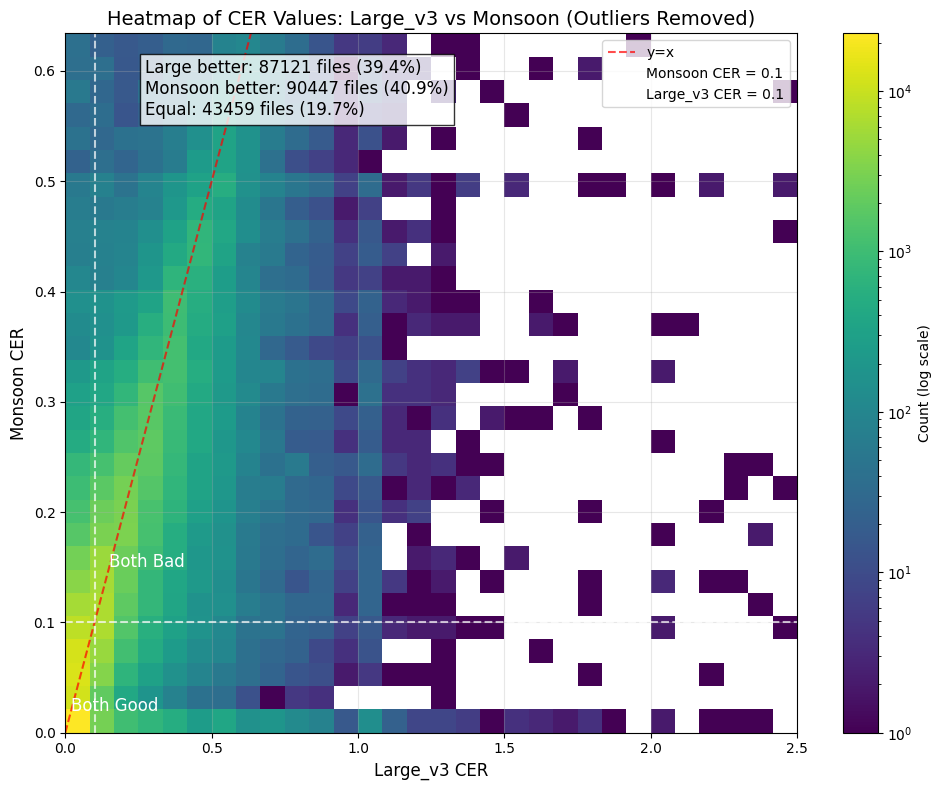

In [6]:
# Merge the dataframes on filename to compare CER values
merged_df = pd.merge(
    df_large[['filename', 'cer']], 
    df_monsoon[['filename', 'cer']], 
    on='filename', 
    suffixes=('_large', '_monsoon')
)

# Function to remove outliers using z-score
def remove_outliers(df, columns, z_threshold=3.0):
    df_clean = df.copy()
    for col in columns:
        z_scores = np.abs(stats.zscore(df_clean[col]))
        df_clean = df_clean[z_scores < z_threshold]
    return df_clean

# Remove outliers
columns_to_check = ['cer_large', 'cer_monsoon']
merged_df_no_outliers = remove_outliers(merged_df, columns_to_check)

print(f"Original data points: {len(merged_df)}")
print(f"After removing outliers: {len(merged_df_no_outliers)}")
print(f"Removed {len(merged_df) - len(merged_df_no_outliers)} outliers")

# Create the 2D histogram/heatmap
plt.figure(figsize=(10, 8))

# Create 2D histogram
h = plt.hist2d(
    merged_df_no_outliers['cer_large'], 
    merged_df_no_outliers['cer_monsoon'],
    bins=30,
    cmap='viridis',
    norm=plt.matplotlib.colors.LogNorm()  # Logarithmic color scale for better visualization
)

# Add colorbar
plt.colorbar(h[3], label='Count (log scale)')

# Plot diagonal line (y=x)
max_cer = max(merged_df_no_outliers['cer_large'].max(), merged_df_no_outliers['cer_monsoon'].max())
plt.plot([0, max_cer], [0, max_cer], 'r--', alpha=0.7, label='y=x')

# Plot threshold lines
plt.axhline(y=0.1, color='white', linestyle='--', alpha=0.7, label='Monsoon CER = 0.1')
plt.axvline(x=0.1, color='white', linestyle='--', alpha=0.7, label='Large_v3 CER = 0.1')

# Add quadrant labels
plt.text(0.02, 0.02, 'Both Good', fontsize=12, color='white')
plt.text(0.15, 0.02, '', fontsize=12, color='white')
plt.text(0.02, 0.15, '', fontsize=12, color='white')
plt.text(0.15, 0.15, 'Both Bad', fontsize=12, color='white')

# Customize plot
plt.xlabel('Large_v3 CER', fontsize=12)
plt.ylabel('Monsoon CER', fontsize=12)
plt.title('Heatmap of CER Values: Large_v3 vs Monsoon (Outliers Removed)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# Calculate which model has better overall performance
better_count = (merged_df_no_outliers['cer_large'] > merged_df_no_outliers['cer_monsoon']).sum()
worse_count = (merged_df_no_outliers['cer_large'] < merged_df_no_outliers['cer_monsoon']).sum()
equal_count = (merged_df_no_outliers['cer_large'] == merged_df_no_outliers['cer_monsoon']).sum()

# Add a textbox with statistics
stats_text = (
    f"Large better: {worse_count} files ({worse_count/len(merged_df_no_outliers):.1%})\n"
    f"Monsoon better: {better_count} files ({better_count/len(merged_df_no_outliers):.1%})\n"
    f"Equal: {equal_count} files ({equal_count/len(merged_df_no_outliers):.1%})"
)
plt.figtext(0.15, 0.85, stats_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()